In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("orvile/eye-diseases-classification")

print("Path to dataset files:", path)

100%|██████████| 40.2M/40.2M [00:03<00:00, 11.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/orvile/eye-diseases-classification/versions/1


In [2]:
import os

print(os.listdir(path))

['Image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid) with Symptoms and SMOTE Validation']


In [3]:
import os

dataset_path = path + "/Image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid) with Symptoms and SMOTE Validation"
print(os.listdir(dataset_path))

['Eyelid', 'Conjunctivitis', 'Cataract', 'Uveitis', 'Normal']


In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

dataset_path = path + "/Image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid) with Symptoms and SMOTE Validation"
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(dataset_path, transform=transform)

loader = DataLoader(dataset, batch_size=32, shuffle=True)

print(dataset.classes)

['Cataract', 'Conjunctivitis', 'Eyelid', 'Normal', 'Uveitis']


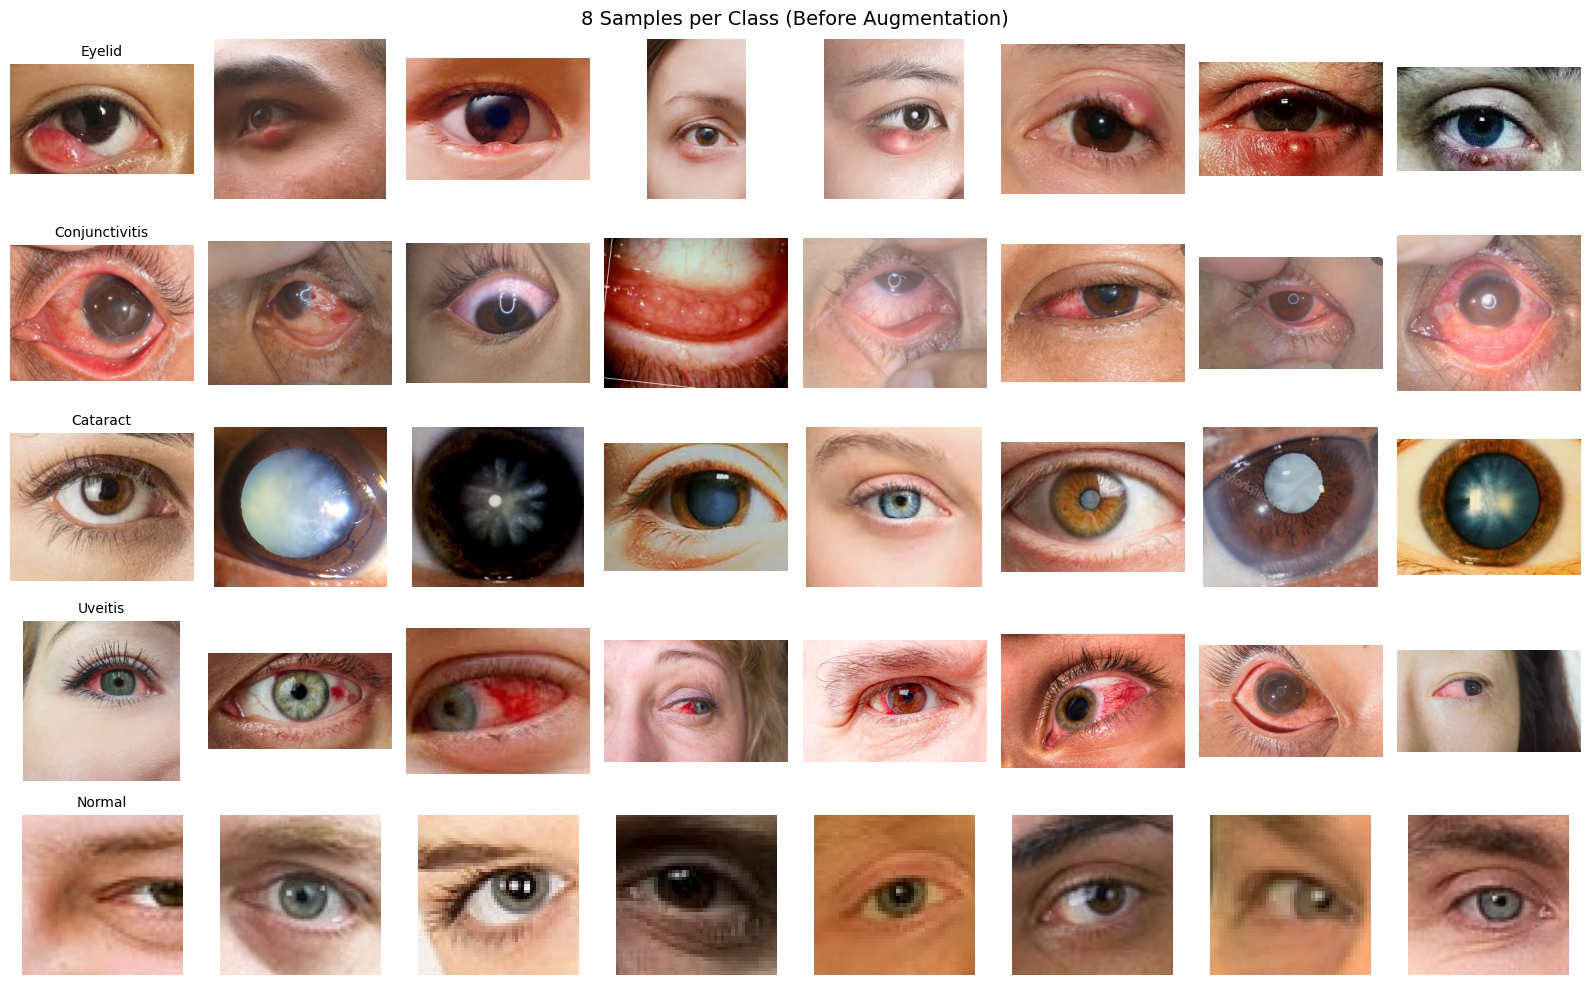

In [5]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = path + "/Image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid) with Symptoms and SMOTE Validation"
classes = os.listdir(dataset_path)

fig, axes = plt.subplots(len(classes), 8, figsize=(16, 10))

for i, cls in enumerate(classes):
    class_path = os.path.join(dataset_path, cls)
    images = os.listdir(class_path)

    sampled_images = random.sample(images, 8)

    for j, img_name in enumerate(sampled_images):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path).convert("RGB")

        axes[i, j].imshow(img)
        axes[i, j].axis("off")

        # فقط روی اولین ستون label بنویس
        if j == 0:
            axes[i, j].set_title(cls, fontsize=10)

plt.suptitle("8 Samples per Class (Before Augmentation)", fontsize=14)
plt.tight_layout()
plt.show()

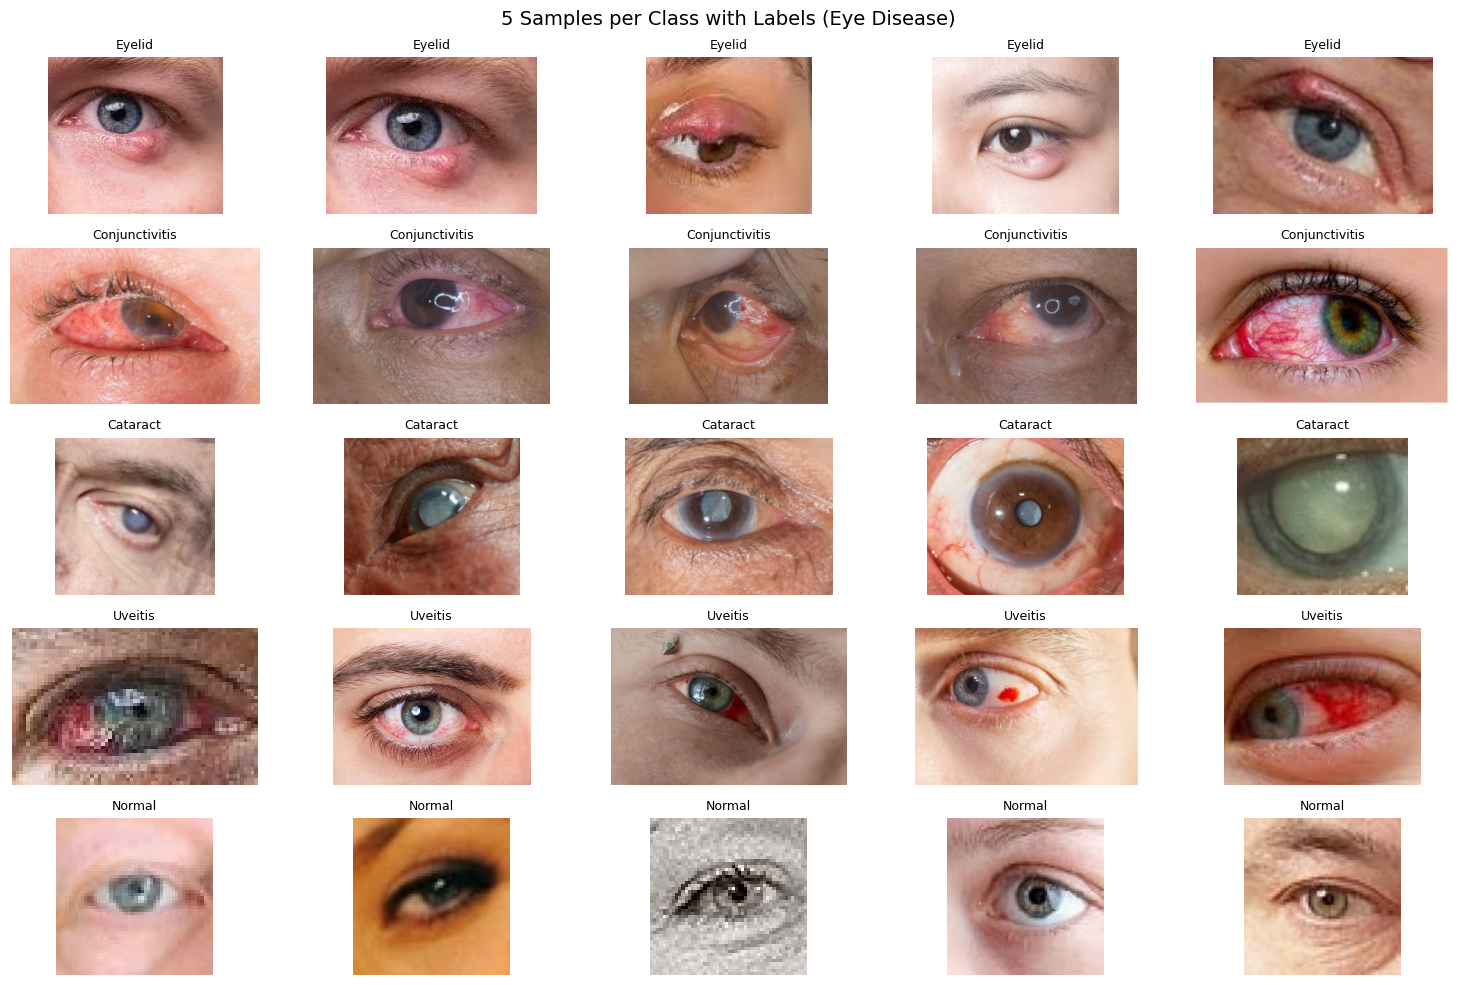

In [6]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = path + "/Image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid) with Symptoms and SMOTE Validation"
classes = os.listdir(dataset_path)

fig, axes = plt.subplots(len(classes), 5, figsize=(15, 10))

for i, cls in enumerate(classes):
    class_path = os.path.join(dataset_path, cls)
    images = os.listdir(class_path)

    sampled_images = random.sample(images, 5)

    for j, img_name in enumerate(sampled_images):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path).convert("RGB")

        axes[i, j].imshow(img)
        axes[i, j].axis("off")

        # ✔ برچسب روی هر تصویر
        axes[i, j].set_title(cls, fontsize=9)

plt.suptitle("5 Samples per Class with Labels (Eye Disease)", fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

dataset_path = path + "/Image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid) with Symptoms and SMOTE Validation"
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(dataset_path, transform=transform)

train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

print("Classes:", dataset.classes)
print("Total images:", len(dataset))

Classes: ['Cataract', 'Conjunctivitis', 'Eyelid', 'Normal', 'Uveitis']
Total images: 2298


In [8]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler

dataset_path = path + "/Image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid) with Symptoms and SMOTE Validation"
dataset = datasets.ImageFolder(dataset_path)

class_counts = [0] * len(dataset.classes)

for _, label in dataset.samples:
    class_counts[label] += 1

print("Class counts:", dict(zip(dataset.classes, class_counts)))

Class counts: {'Cataract': 544, 'Conjunctivitis': 357, 'Eyelid': 525, 'Normal': 649, 'Uveitis': 223}


In [9]:
from torchvision import datasets

dataset = datasets.ImageFolder(dataset_path)
print(dataset.classes)
print(len(dataset))

['Cataract', 'Conjunctivitis', 'Eyelid', 'Normal', 'Uveitis']
2298


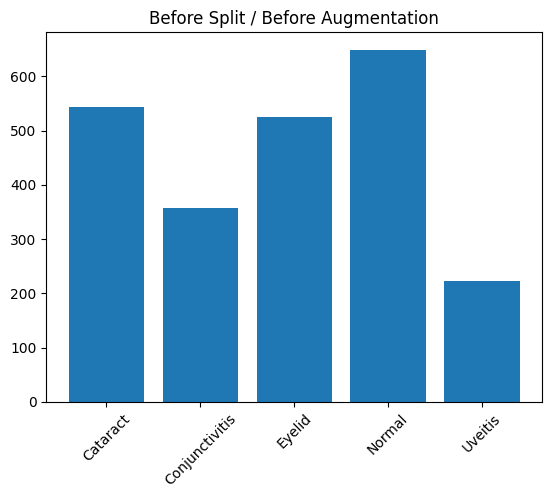

In [10]:
import os
import matplotlib.pyplot as plt

class_counts = {}

for c in dataset.classes:
    class_dir = os.path.join(dataset_path, c)
    class_counts[c] = len(os.listdir(class_dir))

plt.bar(class_counts.keys(), class_counts.values())
plt.title("Before Split / Before Augmentation")
plt.xticks(rotation=45)
plt.show()

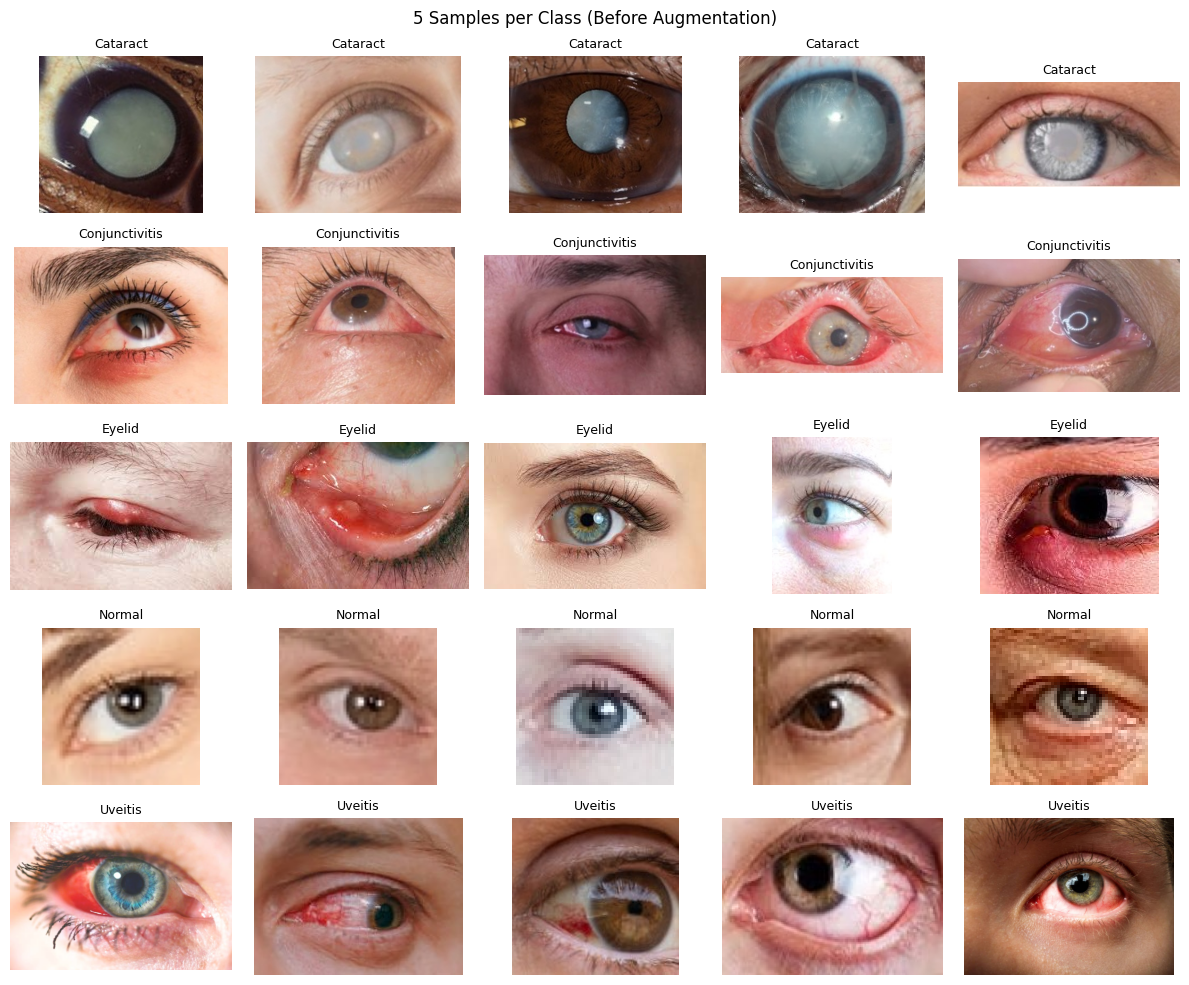

In [11]:
import random
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(dataset.classes), 5, figsize=(12,10))

for i, cls in enumerate(dataset.classes):
    class_path = os.path.join(dataset_path, cls)
    images = os.listdir(class_path)

    samples = random.sample(images, 5)

    for j, img_name in enumerate(samples):
        img = Image.open(os.path.join(class_path, img_name)).convert("RGB")

        axes[i,j].imshow(img)
        axes[i,j].axis("off")
        axes[i,j].set_title(cls, fontsize=9)

plt.suptitle("5 Samples per Class (Before Augmentation)")
plt.tight_layout()
plt.show()


Image count per class:
Cataract: 544
Conjunctivitis: 357
Eyelid: 525
Normal: 649
Uveitis: 223


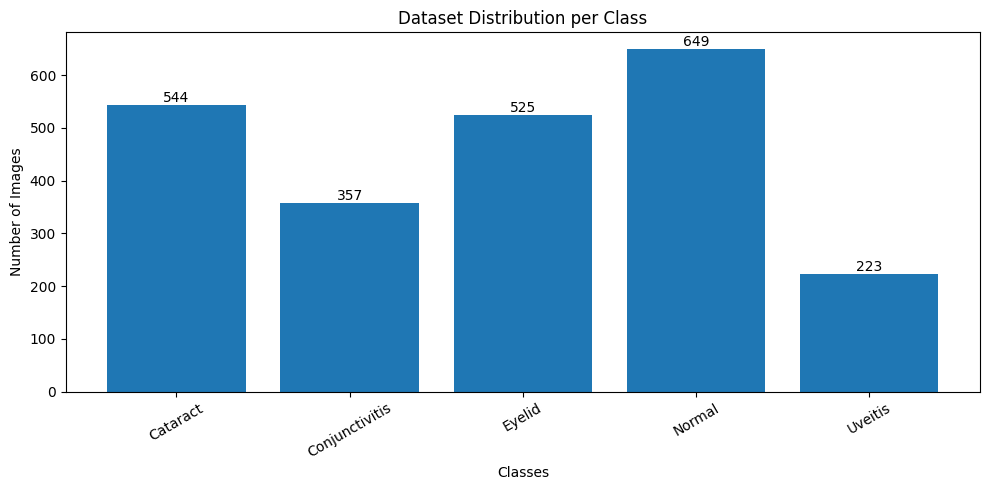

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Path to your dataset
dataset_path = path + "/Image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid) with Symptoms and SMOTE Validation"

image_ext = ('.jpg', '.jpeg', '.png')

# Get classes automatically
classes = sorted([
    c for c in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, c))
])

def count_images(class_name):
    folder_path = os.path.join(dataset_path, class_name)
    if not os.path.exists(folder_path):
        return 0

    return len([
        f for f in os.listdir(folder_path)
        if f.lower().endswith(image_ext)
    ])

# Build count vector (single row since no train/val/test split)
counts = np.array([count_images(c) for c in classes])

print("\nImage count per class:")
for c, n in zip(classes, counts):
    print(f"{c}: {n}")

# Plot bar chart
plt.figure(figsize=(10,5))
plt.bar(classes, counts)

plt.title("Dataset Distribution per Class")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)

# Add numbers on bars
for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [13]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import pandas as pd

# Correct path from the kagglehub download
base_path = path # Corrected: Use the global 'path' variable from kagglehub download
inner_folder = "Image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid) with Symptoms and SMOTE Validation"
dataset_path = os.path.join(base_path, inner_folder)

image_ext = ('.jpg', '.jpeg', '.png')

def prepare_dataset_splits(dataset_path, train_size=0.7, val_size=0.15, test_size=0.15, random_state=42):
    assert abs((train_size + val_size + test_size) - 1.0) < 1e-9
    classes = sorted([c for c in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, c))])
    all_filepaths = []
    all_labels = []
    for class_idx, class_name in enumerate(classes):
        folder_path = os.path.join(dataset_path, class_name)
        files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.lower().endswith(image_ext)]
        all_filepaths.extend(files)
        all_labels.extend([class_idx] * len(files))

    all_filepaths = np.array(all_filepaths)
    all_labels = np.array(all_labels)
    X_train, X_temp, y_train, y_temp = train_test_split(all_filepaths, all_labels, train_size=train_size, stratify=all_labels, random_state=random_state)
    rel_val = val_size / (val_size + test_size)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=rel_val, stratify=y_temp, random_state=random_state)

    pd.DataFrame({'filepath': X_train, 'label': y_train}).to_csv('train_split.csv', index=False)
    pd.DataFrame({'filepath': X_val, 'label': y_val}).to_csv('val_split.csv', index=False)
    pd.DataFrame({'filepath': X_test, 'label': y_test}).to_csv('test_split.csv', index=False)

    weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    print(f"Created CSVs for {len(all_labels)} images. Classes: {classes}")
    return weights, classes

if os.path.exists(dataset_path):
    weights, class_names = prepare_dataset_splits(dataset_path)
else:
    print(f"Still cannot find: {dataset_path}")

Created CSVs for 2298 images. Classes: ['Cataract', 'Conjunctivitis', 'Eyelid', 'Normal', 'Uveitis']


In [14]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import os

class EyeDiseaseDataset(Dataset):
    """Custom Dataset for reading paths and labels from our generated CSVs."""

    def __init__(self, csv_file, transform=None):
        """
        Args:
            csv_file (string): Path to the csv file with filepaths and labels.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.data_frame = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        # Read the filepath from the first column of the CSV
        img_name = self.data_frame.iloc[idx, 0]

        # Open image and convert to RGB (handles grayscale or RGBA images safely)
        image = Image.open(img_name).convert('RGB')

        # Read the label from the second column
        label = int(self.data_frame.iloc[idx, 1])

        # Apply augmentations/transforms if provided
        if self.transform:
            image = self.transform(image)

        return image, label


def get_dataloaders(batch_size=32, img_size=224):
    """
    Sets up the DataLoaders with specific augmentations for training
    and standard transforms for validation/testing.
    """

    # 1. Data Augmentation for Training
    # This helps the model generalize, especially for minority classes like Uveitis
    train_transforms = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(p=0.5),          # Randomly flip images horizontally
        transforms.RandomRotation(degrees=15),           # Randomly rotate by up to 15 degrees
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Slight color/lighting changes
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], # Standard ImageNet normalization means
                             std=[0.229, 0.224, 0.225])  # Standard ImageNet normalization stds
    ])

    # 2. Basic transforms for Validation and Testing
    # We NEVER augment validation or test data!
    val_test_transforms = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    # 3. Instantiate the Custom Datasets
    train_dataset = EyeDiseaseDataset(csv_file='train_split.csv', transform=train_transforms)
    val_dataset = EyeDiseaseDataset(csv_file='val_split.csv', transform=val_test_transforms)
    test_dataset = EyeDiseaseDataset(csv_file='test_split.csv', transform=val_test_transforms)

    # 4. Instantiate the DataLoaders
    # num_workers speeds up data loading, pin_memory speeds up CPU to GPU transfer
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader


if __name__ == "__main__":
    # Test the DataLoaders
    print("Initializing DataLoaders...")
    train_loader, val_loader, test_loader = get_dataloaders(batch_size=32)

    print(f"Number of training batches: {len(train_loader)}")
    print(f"Number of validation batches: {len(val_loader)}")

    # Fetch a single batch to verify shapes
    images, labels = next(iter(train_loader))
    print(f"\nBatch image shape: {images.shape}") # Should be [32, 3, 224, 224]
    print(f"Batch label shape: {labels.shape}")   # Should be [32]

    # The weights you generated in the previous step go directly into your loss function!
    # Example snippet for when you build your training loop:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    class_weights = torch.tensor([0.8441, 1.2864, 0.8763, 0.7084, 2.0615], dtype=torch.float32).to(device)
    criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

    print("\nDataset pipeline is fully ready for model training!")

Initializing DataLoaders...
Number of training batches: 51
Number of validation batches: 11

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])

Dataset pipeline is fully ready for model training!



Count matrix (rows=train, val, test):
[[381 250 367 454 156]
 [ 81  54  79  97  34]
 [ 82  53  79  98  33]]


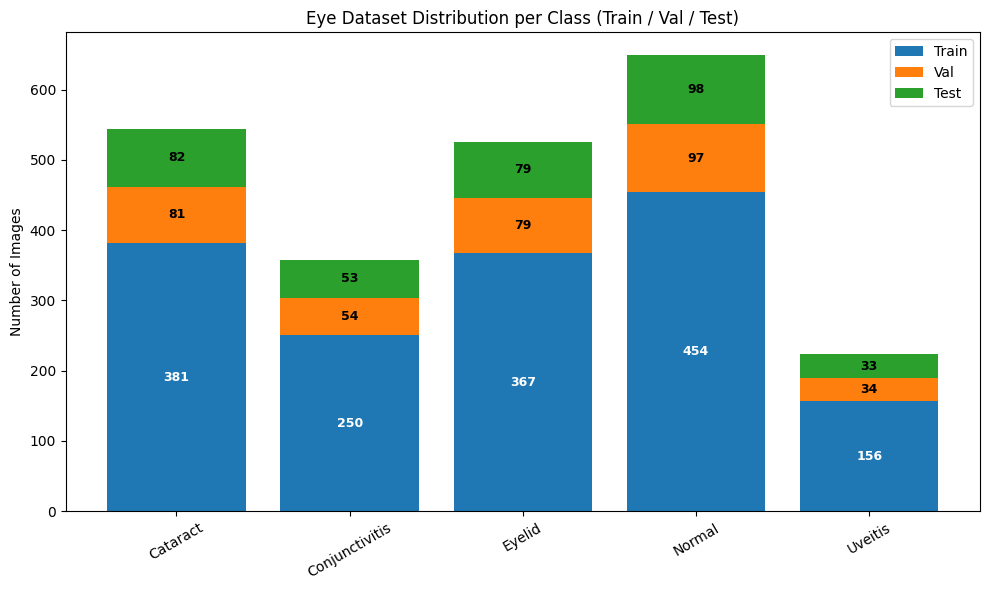

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ==============================================================================
# METHODOLOGY JUSTIFICATION FOR PAPER (Handling Class Imbalance)
# ==============================================================================
# 1. Stratified Splitting: The dataset was split using stratification to ensure
#    the original class distribution is strictly preserved across Train, Validation,
#    and Test sets. This prevents evaluation bias.
# 2. Class Weighting: Class weights were calculated (higher weights for minority
#    classes like Uveitis) and applied to the loss function (e.g., CrossEntropyLoss)
#    to prevent the model from ignoring underrepresented classes.
# 3. Safe Data Augmentation: Augmentation techniques (rotation, flipping, etc.)
#    were applied ONLY to the training set to prevent overfitting and enrich
#    minority classes, ensuring zero data leakage to validation/test sets.
# 4. Robust Evaluation Metrics: Due to the mild-to-moderate imbalance, evaluation
#    relies on metrics like F1-Score, Balanced Accuracy, and AUC, rather than
#    relying solely on standard Accuracy.
# ==============================================================================

# The classes are indexed alphabetically based on our previous setup
classes = ['Cataract', 'Conjunctivitis', 'Eyelid', 'Normal', 'Uveitis']
splits = ['train', 'val', 'test']

# Set this to the directory where your CSV files are saved.
# In Kaggle, you might need to change this to '/kaggle/working/'
csv_dir = './'

def get_counts_from_csv():
    counts = []
    for split in splits:
        csv_file = f"{split}_split.csv"
        csv_path = os.path.join(csv_dir, csv_file)

        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            # Count occurrences of each label (0 to 4)
            split_counts = [len(df[df['label'] == i]) for i in range(len(classes))]
            counts.append(split_counts)
        else:
            print(f"Warning: {csv_path} not found. Filling with zeros.")
            counts.append([0] * len(classes))
    return np.array(counts)

# Build count matrix (shape = 3, num_classes)
counts = get_counts_from_csv()

print("\nCount matrix (rows=train, val, test):")
print(counts)

# Plot the chart
x = np.arange(len(classes))
fig, ax = plt.subplots(figsize=(10, 6))

bottom = np.zeros(len(classes))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue for train, Orange for val, Green for test

for i, split in enumerate(splits):
    ax.bar(x, counts[i], bottom=bottom, label=split.capitalize(), color=colors[i])
    bottom += counts[i]

ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=30)
ax.set_ylabel("Number of Images")
ax.set_title("Eye Dataset Distribution per Class (Train / Val / Test)")
ax.legend()

# Add numeric labels on the bars
bottom = np.zeros(len(classes))
for i in range(len(splits)):
    for j in range(len(classes)):
        height = counts[i][j]
        if height > 0:
            ax.text(
                j,
                bottom[j] + height / 2,
                str(height),
                ha='center',
                va='center',
                fontsize=9,
                color='white' if i == 0 else 'black', # Make text visible based on bar color
                fontweight='bold'
            )
    bottom += counts[i]

plt.tight_layout()
plt.show()


Count matrix (rows=train, val, test):
[[381 250 367 454 156]
 [ 81  54  79  97  34]
 [ 82  53  79  98  33]]


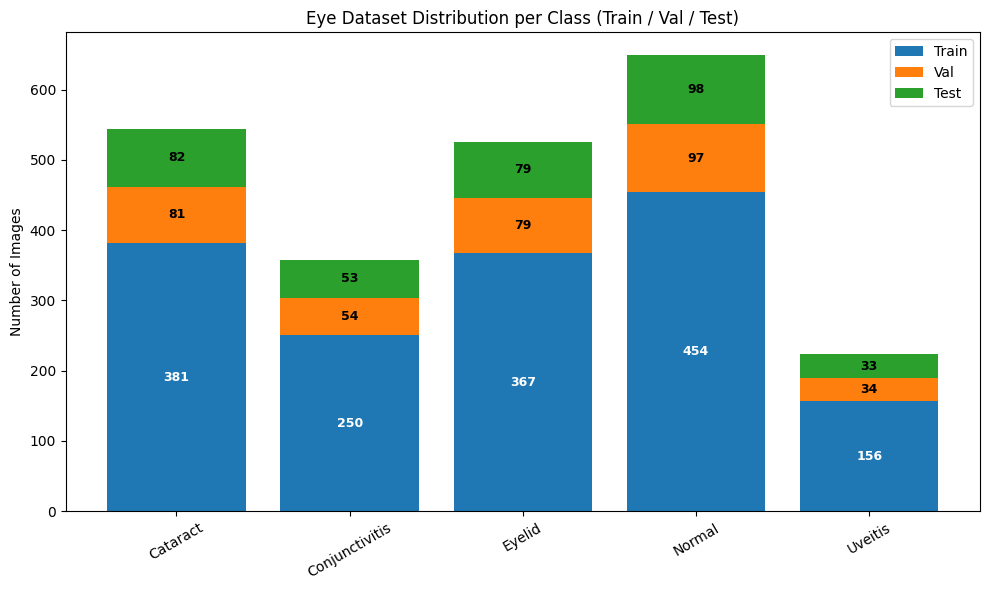

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ==============================================================================
# METHODOLOGY JUSTIFICATION FOR PAPER (Handling Class Imbalance)
# ==============================================================================
# 1. Stratified Splitting: The dataset was split using stratification to ensure
#    the original class distribution is strictly preserved across Train, Validation,
#    and Test sets. This prevents evaluation bias.
# 2. Class Weighting: Class weights were calculated (higher weights for minority
#    classes like Uveitis) and applied to the loss function (e.g., CrossEntropyLoss)
#    to prevent the model from ignoring underrepresented classes.
# 3. Safe Data Augmentation: Augmentation techniques (rotation, flipping, etc.)
#    were applied ONLY to the training set to prevent overfitting and enrich
#    minority classes, ensuring zero data leakage to validation/test sets.
# 4. Robust Evaluation Metrics: Due to the mild-to-moderate imbalance, evaluation
#    relies on metrics like F1-Score, Balanced Accuracy, and AUC, rather than
#    relying solely on standard Accuracy.
# ==============================================================================

# The classes are indexed alphabetically based on our previous setup
classes = ['Cataract', 'Conjunctivitis', 'Eyelid', 'Normal', 'Uveitis']
splits = ['train', 'val', 'test']

def get_counts_from_csv():
    counts = []
    for split in splits:
        csv_file = f"{split}_split.csv"
        if os.path.exists(csv_file):
            df = pd.read_csv(csv_file)
            # Count occurrences of each label (0 to 4)
            split_counts = [len(df[df['label'] == i]) for i in range(len(classes))]
            counts.append(split_counts)
        else:
            print(f"Warning: {csv_file} not found. Filling with zeros.")
            counts.append([0] * len(classes))
    return np.array(counts)

# Build count matrix (shape = 3, num_classes)
counts = get_counts_from_csv()

print("\nCount matrix (rows=train, val, test):")
print(counts)

# Plot the chart
x = np.arange(len(classes))
fig, ax = plt.subplots(figsize=(10, 6))

bottom = np.zeros(len(classes))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue for train, Orange for val, Green for test

for i, split in enumerate(splits):
    ax.bar(x, counts[i], bottom=bottom, label=split.capitalize(), color=colors[i])
    bottom += counts[i]

ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=30)
ax.set_ylabel("Number of Images")
ax.set_title("Eye Dataset Distribution per Class (Train / Val / Test)")
ax.legend()

# Add numeric labels on the bars
bottom = np.zeros(len(classes))
for i in range(len(splits)):
    for j in range(len(classes)):
        height = counts[i][j]
        if height > 0:
            ax.text(
                j,
                bottom[j] + height / 2,
                str(height),
                ha='center',
                va='center',
                fontsize=9,
                color='white' if i == 0 else 'black', # Make text visible based on bar color
                fontweight='bold'
            )
    bottom += counts[i]

plt.tight_layout()
plt.show()

In [17]:
!pip install thop

In [18]:
# =========================================================================
# 5-FOLD CROSS VALIDATION PIPELINE (WARNINGS FIXED)
# =========================================================================

import os, random, time, gc, glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, cohen_kappa_score,
                             matthews_corrcoef, log_loss, roc_auc_score,
                             brier_score_loss)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import resample
from scipy.optimize import minimize
from scipy.stats import wilcoxon
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
from tqdm import tqdm
from PIL import Image
import kagglehub
import warnings

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

# ------------------------------------------------------------------
# 1. Configuration and globals
# ------------------------------------------------------------------
SEED = 42
EPOCHS = 30
PATIENCE = 3
BATCH = 64
LR = 5e-4
WARMUP_EPOCHS = 3
MIXUP_ALPHA = 0.2
IMG_SIZE = 224

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0

CLASSES = []
N_CLASSES = 0
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
LABEL_SMOOTHING = 0.1

SAVE_DIR = './results'
LATEX_DIR = os.path.join(SAVE_DIR, 'latex_tables')
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(LATEX_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ------------------------------------------------------------------
# 2. Data Preparation & Transforms
# ------------------------------------------------------------------
def prepare_data():
    global CLASSES, N_CLASSES
    print("Downloading/Loading dataset via kagglehub...")
    path = kagglehub.dataset_download('gunavenkatdoddi/eye-diseases-classification')

    data_root = os.path.join(path, 'dataset')
    if not os.path.exists(data_root):
        data_root = path

    raw_classes = sorted([d for d in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, d))])
    CLASSES = ['Cataract', 'Diabetic Retinopathy', 'Glaucoma', 'Normal']
    N_CLASSES = len(CLASSES)

    all_image_paths, all_labels = [], []
    for idx, cls_name_raw in enumerate(raw_classes):
        cls_folder = os.path.join(data_root, cls_name_raw)
        images = glob.glob(os.path.join(cls_folder, "*"))
        images = [img for img in images if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        for img_path in images:
            all_image_paths.append(img_path)
            all_labels.append(idx)

    X_train, X_temp, y_train, y_temp = train_test_split(all_image_paths, all_labels, test_size=0.3, stratify=all_labels, random_state=SEED)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)

    tr_list = list(zip(X_train, y_train))
    va_list = list(zip(X_val, y_val))
    return tr_list, va_list

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=20, p=0.7),
    A.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1, p=0.5),
    A.CoarseDropout(p=0.5),
    A.CLAHE(p=0.3),
    A.ElasticTransform(alpha=1, sigma=50, p=0.3),
    A.Normalize(MEAN, STD),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(MEAN, STD),
    ToTensorV2()
])

class MedicalDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = np.array(Image.open(path).convert('RGB'))
        except Exception:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

        if self.transform:
            img = self.transform(image=img)['image']
        return img, F.one_hot(torch.tensor(label), N_CLASSES).float()

# ------------------------------------------------------------------
# 3. Model Architecture
# ------------------------------------------------------------------
class SEBlock(nn.Module):
    def __init__(self, c, r=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(c, c // r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(c // r, c, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        bs, c, _, _ = x.shape
        y = self.squeeze(x).view(bs, c)
        y = self.excitation(y).view(bs, c, 1, 1)
        return x * y.expand_as(x)

class LearnableAdjacency(nn.Module):
    def __init__(self, n_classes, init_adj=None):
        super().__init__()
        if init_adj is None:
            init_adj = torch.eye(n_classes) + 0.1
        self.adj = nn.Parameter(init_adj.clone(), requires_grad=True)
    def forward(self):
        adj = F.relu(self.adj)
        adj = (adj + adj.t()) / 2
        adj = adj / (adj.sum(1).unsqueeze(1) + 1e-9)
        return adj

class CustomModel(nn.Module):
    def __init__(self, model_name='densenet121', pretrained=True, adj=None,
                 use_se=True, use_gcn=True, use_multi_task=True, learnable_adj=False):
        super().__init__()
        self.model_name = model_name
        self.model = timm.create_model(model_name, pretrained=pretrained, num_classes=0, global_pool='')

        with torch.no_grad():
            out = self.model(torch.randn(2, 3, IMG_SIZE, IMG_SIZE))
        self.is_vit = (out.dim() == 3)

        self.n_features = out.shape[-1] if self.is_vit else out.shape[1]
        self.use_se = use_se and not self.is_vit
        self.attention = SEBlock(self.n_features) if self.use_se else nn.Identity()

        if self.is_vit:
            self.pool = lambda x: x.mean(dim=1)
        else:
            self.pool = nn.AdaptiveAvgPool2d(1)

        self.use_multi_task = use_multi_task
        if use_multi_task:
            self.heads = nn.ModuleList([
                nn.Sequential(
                    nn.Linear(self.n_features, 512),
                    nn.BatchNorm1d(512),
                    nn.ReLU(inplace=True),
                    nn.Dropout(0.6),
                    nn.Linear(512, 1)
                ) for _ in range(N_CLASSES)
            ])
        else:
            self.classifier = nn.Sequential(
                nn.Linear(self.n_features, 512),
                nn.BatchNorm1d(512),
                nn.ReLU(inplace=True),
                nn.Dropout(0.6),
                nn.Linear(512, N_CLASSES)
            )

        self.use_gcn = use_gcn
        self.learnable_adj = learnable_adj
        if use_gcn:
            if learnable_adj:
                self.adj = LearnableAdjacency(N_CLASSES, init_adj=adj)
            else:
                self.adj = adj if adj is not None else torch.eye(N_CLASSES)

    def forward(self, x):
        features = self.model(x)
        if not self.is_vit:
            features = self.attention(features)
            pooled = self.pool(features)
            flattened = torch.flatten(pooled, 1)
        else:
            features = self.attention(features)
            flattened = self.pool(features)

        logits = torch.cat([head(flattened) for head in self.heads], dim=1) \
                 if self.use_multi_task else self.classifier(flattened)

        if self.use_gcn:
            adj_matrix = self.adj() if self.learnable_adj else self.adj.to(logits.device)
            logits = logits + F.relu(torch.matmul(adj_matrix, logits.t())).t()
        return logits

# ------------------------------------------------------------------
# 4. Utilities & Training Logic
# ------------------------------------------------------------------
class FocalLoss(nn.Module):
    def __init__(self, weight=None, alpha=1.0, gamma=2, label_smoothing=0.0):
        super().__init__()
        self.weight = weight
        self.alpha = alpha
        self.gamma = gamma
        self.smoothing = label_smoothing

    def forward(self, logits, targets):
        if self.smoothing > 0:
            targets = targets * (1 - self.smoothing) + self.smoothing / N_CLASSES
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        f_loss = self.alpha * (1 - torch.exp(-bce_loss)) ** self.gamma * bce_loss
        if self.weight is not None:
            f_loss = f_loss * self.weight.to(logits.device)
        return f_loss.mean()

def compute_macro_specificity(cm):
    specs = []
    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        specs.append(tn / (tn + fp + 1e-9))
    return np.mean(specs)

def bootstrap_metrics(y_true, y_pred, y_prob, n_iterations=1000, alpha=0.95, return_dict=True):
    # 🌟 FIX: Force exact float64 normalization to silence sklearn warnings
    y_prob = np.array(y_prob, dtype=np.float64)
    y_prob /= np.sum(y_prob, axis=1, keepdims=True)

    metrics = {'Accuracy': [], 'Balanced Acc': [], 'Precision': [], 'Recall': [],
               'F1-Score': [], 'Specificity': [], "Cohen's Kappa": [], 'MCC': [],
               'Log Loss': [], 'Brier Score': [], 'AUC': []}
    n_size = len(y_true)

    for _ in range(n_iterations):
        idx = resample(np.arange(n_size))
        yt, yp, yprob = y_true[idx], y_pred[idx], y_prob[idx]
        if len(np.unique(yt)) < 2: continue

        metrics['Accuracy'].append(accuracy_score(yt, yp))
        metrics['Balanced Acc'].append(balanced_accuracy_score(yt, yp))
        metrics['Precision'].append(precision_score(yt, yp, average='weighted', zero_division=0))
        metrics['Recall'].append(recall_score(yt, yp, average='weighted', zero_division=0))
        metrics['F1-Score'].append(f1_score(yt, yp, average='weighted', zero_division=0))

        cm = confusion_matrix(yt, yp, labels=range(N_CLASSES))
        metrics['Specificity'].append(compute_macro_specificity(cm))
        metrics["Cohen's Kappa"].append(cohen_kappa_score(yt, yp))
        metrics['MCC'].append(matthews_corrcoef(yt, yp))

        try: metrics["Log Loss"].append(log_loss(yt, yprob, labels=range(N_CLASSES)))
        except: pass
        metrics['Brier Score'].append(np.mean([brier_score_loss((yt == i).astype(int), yprob[:, i]) for i in range(N_CLASSES)]))
        try:
            auc = roc_auc_score(yt, yprob, multi_class="ovo", average="macro") if N_CLASSES > 2 else roc_auc_score(yt, yprob[:, 1])
            metrics['AUC'].append(auc)
        except: pass

    res_str, res_val = {}, {}
    lower_p, upper_p = ((1.0 - alpha) / 2.0) * 100, (alpha + ((1.0 - alpha) / 2.0)) * 100
    for k, v in metrics.items():
        if v:
            m, l, u = np.mean(v), np.percentile(v, lower_p), np.percentile(v, upper_p)
            res_val[k] = m
            if k in ["Log Loss", "Brier Score", "AUC", "Cohen's Kappa", "MCC"]:
                res_str[k] = f"{m:.4f} ({l:.4f}-{u:.4f})"
            else:
                res_str[k] = f"{m*100:.2f} ({l*100:.2f}-{u*100:.2f})"
        else:
            res_str[k], res_val[k] = "N/A", 0.0
    return res_val if return_dict else res_str

def validate_epoch(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    t_labels, p_labels, p_probs = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            loss_sum += loss.item() * x.size(0)

            prob = F.softmax(out, 1)
            pred = prob.argmax(1)
            correct += (pred == y.argmax(1)).sum().item()
            total += x.size(0)

            t_labels.append(y.cpu())
            p_labels.append(pred.cpu())
            p_probs.append(prob.cpu())

    # 🌟 FIX: Upgrade precision to float64 and force sum = 1.0 exactly
    t_labels_np = np.argmax(torch.cat(t_labels).numpy(), 1)
    p_labels_np = torch.cat(p_labels).numpy()
    p_probs_np = torch.cat(p_probs).numpy().astype(np.float64)
    p_probs_np /= np.sum(p_probs_np, axis=1, keepdims=True)

    return (loss_sum / total, correct / total, t_labels_np, p_labels_np, p_probs_np)

def train_model(model, name, train_loader, val_loader, criterion, device, epochs=EPOCHS):
    if NUM_GPUS > 1: model = nn.DataParallel(model)
    model = model.to(device)

    opt = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)

    warmup_scheduler = LinearLR(opt, start_factor=0.01, total_iters=WARMUP_EPOCHS)
    cosine_scheduler = CosineAnnealingLR(opt, T_max=epochs - WARMUP_EPOCHS, eta_min=1e-6)
    sch = SequentialLR(opt, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[WARMUP_EPOCHS])

    scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))
    best_v = float('inf')
    p_count = 0

    try: autocast_ctx = torch.amp.autocast(device_type=device.type)
    except Exception:
        import contextlib
        autocast_ctx = contextlib.nullcontext()

    for ep in range(1, epochs + 1):
        model.train()
        r_loss, r_corr, total = 0.0, 0, 0
        batch_pbar = tqdm(train_loader, desc=f"Ep {ep}/{epochs}", leave=False, unit="batch")

        for x, y in batch_pbar:
            x, y = x.to(device), y.to(device)

            if np.random.rand() < 0.5:
                lam = np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA)
                rand_index = torch.randperm(x.size(0)).to(device)
                x = lam * x + (1 - lam) * x[rand_index, :]
                y = lam * y + (1 - lam) * y[rand_index, :]

            opt.zero_grad(set_to_none=True)
            with autocast_ctx:
                out = model(x)
                loss = criterion(out, y)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            bs = x.size(0)
            r_loss += loss.item() * bs
            total += bs
            batch_pbar.set_postfix(loss=f"{r_loss / total:.4f}")

        v_l, v_a, _, _, _ = validate_epoch(model, val_loader, criterion, device)
        sch.step()

        if v_l < best_v:
            best_v = v_l
            p_count = 0
            model_to_save = model.module if hasattr(model, 'module') else model
            torch.save(model_to_save.state_dict(), os.path.join(SAVE_DIR, f"best_model_{name}.pth"))
        else:
            p_count += 1
            if p_count >= PATIENCE:
                break
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

def ens_eval(probs_list, y_true, w):
    # 🌟 FIX: Upgrade precision and force normalize ensemble probabilities
    avg_p = np.average(np.array(probs_list), axis=0, weights=w).astype(np.float64)
    avg_p /= np.sum(avg_p, axis=1, keepdims=True)
    preds = avg_p.argmax(1)
    return accuracy_score(y_true, preds), avg_p, preds

def save_latex_to_file(content, filename):
    with open(os.path.join(LATEX_DIR, filename), 'w', encoding='utf-8') as f:
        f.write(content)

# ------------------------------------------------------------------
# 5. Main 5-Fold Execution Block
# ------------------------------------------------------------------
def main():
    tr_list, va_list = prepare_data()
    all_train_val = tr_list + va_list

    all_p = np.array([item[0] for item in all_train_val])
    all_l = np.array([item[1] for item in all_train_val]).astype(int)

    ensemble_configs = [
        {'name': 'densenet121',             'backbone': 'densenet121',
         'use_se': True, 'use_gcn': True,  'use_multi_task': True, 'learnable_adj': False},
        {'name': 'densenet121_no_se',       'backbone': 'densenet121',
         'use_se': False,'use_gcn': True,  'use_multi_task': True, 'learnable_adj': False},
        {'name': 'densenet121_no_gcn',      'backbone': 'densenet121',
         'use_se': True, 'use_gcn': False, 'use_multi_task': True, 'learnable_adj': False},
    ]

    cw = compute_class_weight('balanced', classes=np.unique(all_l), y=all_l)
    criterion = FocalLoss(weight=torch.tensor(cw, dtype=torch.float32), label_smoothing=LABEL_SMOOTHING)

    adj = torch.eye(N_CLASSES)
    adj = (adj + 0.05)
    adj.fill_diagonal_(1.0)
    adj /= adj.sum(1).unsqueeze(1)

    print("\n==================================================")
    print("Executing 5-Fold Cross Validation for Ensemble...")
    print("==================================================")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_res, ens_fold_accs, base_fold_accs = [], [], []
    pooled_true, pooled_pred, pooled_prob = [], [], []

    for f, (ti, vi) in enumerate(skf.split(all_p, all_l)):
        print(f"\n=================== FOLD {f+1}/5 ===================")
        f_tr_ld = DataLoader(MedicalDataset(list(zip(all_p[ti], all_l[ti])), transform=train_transform),
                             batch_size=BATCH, shuffle=True, num_workers=2)
        f_va_ld = DataLoader(MedicalDataset(list(zip(all_p[vi], all_l[vi])), transform=val_transform),
                             batch_size=BATCH, num_workers=2)

        f_t = np.argmax(torch.cat([y for _, y in f_va_ld]).numpy(), 1)
        f_probs = []

        for idx, c in enumerate(ensemble_configs):
            print(f"\n🔹 Training Fold {f+1} - Model: {c['name']}")
            m_i = CustomModel(c['backbone'], adj=adj,
                              use_se=c['use_se'], use_gcn=c['use_gcn'],
                              use_multi_task=c['use_multi_task'],
                              learnable_adj=c['learnable_adj'])

            train_model(m_i, f"fold_{f+1}_{c['name']}", f_tr_ld, f_va_ld, criterion, DEVICE, epochs=EPOCHS)

            m_i.load_state_dict(torch.load(os.path.join(SAVE_DIR, f"best_model_fold_{f+1}_{c['name']}.pth")))
            _, _, _, _, f_pb = validate_epoch(m_i, f_va_ld, criterion, DEVICE)
            f_probs.append(f_pb)

            if idx == 0:
                base_fold_accs.append(accuracy_score(f_t, f_pb.argmax(1)))

            del m_i
            gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()

        # 🌟 FIX: Apply precise normalizations to SLSQP target function
        def fold_obj(w):
            w_norm = w / (np.sum(w) + 1e-9)
            a_p = np.average(f_probs, axis=0, weights=w_norm).astype(np.float64)
            a_p /= np.sum(a_p, axis=1, keepdims=True)
            a_p = np.clip(a_p, 1e-15, 1 - 1e-15)
            a_p /= np.sum(a_p, axis=1, keepdims=True) # re-normalize after clipping
            return log_loss(f_t, a_p)

        n_models = len(ensemble_configs)
        init_guess = [1.0 / n_models] * n_models
        bounds = [(0.0, 1.0)] * n_models
        cons = ({'type': 'eq', 'fun': lambda w: 1.0 - np.sum(w)})

        f_res = minimize(fold_obj, init_guess, method='SLSQP', bounds=bounds, constraints=cons)
        f_opt_weights = f_res.x / (np.sum(f_res.x) + 1e-9)

        _, avg_f, pr_f = ens_eval(f_probs, f_t, f_opt_weights)

        ens_fold_accs.append(accuracy_score(f_t, pr_f))
        fold_metrics = bootstrap_metrics(f_t, pr_f, avg_f, return_dict=False)
        fold_metrics['Fold'] = f"Fold {f+1}"
        cv_res.append(fold_metrics)

        pooled_true.extend(f_t)
        pooled_pred.extend(pr_f)
        pooled_prob.extend(avg_f)

    pooled_metrics = bootstrap_metrics(np.array(pooled_true), np.array(pooled_pred), np.array(pooled_prob), return_dict=False)
    pooled_metrics['Fold'] = "Pooled CV"
    cv_res.append(pooled_metrics)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try: _, p_val_w = wilcoxon(ens_fold_accs, base_fold_accs)
        except: p_val_w = 1.0

    kappa_key = "Cohen's Kappa"

    table1_latex = "\\section*{Table 1 5-Fold CV}\n\\begin{table}[H]\n\\caption{Stratified 5-fold cross-validation results for the ensemble model. Wilcoxon Signed-Rank test confirms stability vs best baseline (p=" + f"{p_val_w:.4f}" + ").}\n\\label{tab:5fold_cv}\n\\centering\n\\footnotesize\n\\setlength{\\tabcolsep}{4pt}\n\\begin{tabular}{l *{11}{c}}\n\\toprule\nFold & \\rotatebox{90}{Accuracy (95\\% CI)} & \\rotatebox{90}{Bal Acc (95\\% CI)} & \\rotatebox{90}{Precision (95\\% CI)} & \\rotatebox{90}{Recall (95\\% CI)} & \\rotatebox{90}{F1-Score (95\\% CI)} & \\rotatebox{90}{Specificity (95\\% CI)} & \\rotatebox{90}{Cohen's $\\kappa$ (95\\% CI)} & \\rotatebox{90}{MCC (95\\% CI)} & \\rotatebox{90}{Log Loss (95\\% CI)} & \\rotatebox{90}{Brier Score (95\\% CI)} & \\rotatebox{90}{AUC (95\\% CI)} \\\\\n\\midrule\n"
    for res in cv_res:
        if res['Fold'] == "Pooled CV": table1_latex += "\\midrule\n"
        table1_latex += (res['Fold'] + " & " + res['Accuracy'] + " & " + res['Balanced Acc'] + " & " +
                         res['Precision'] + " & " + res['Recall'] + " & " + res['F1-Score'] + " & " +
                         res['Specificity'] + " & " + res[kappa_key] + " & " + res['MCC'] + " & " +
                         res['Log Loss'] + " & " + res['Brier Score'] + " & " + res['AUC'] + " \\\\\n")
    table1_latex += "\\bottomrule\n\\end{tabular}\n\\end{table}"

    save_latex_to_file(table1_latex, 'table_1_5fold_cv.tex')
    print(f"\n5-Fold CV Completed. Metrics and Table saved to {LATEX_DIR}")

if __name__ == "__main__":
    main()

Downloading/Loading dataset via kagglehub...


100%|██████████| 736M/736M [00:44<00:00, 17.4MB/s]

Extracting files...



Executing 5-Fold Cross Validation for Ensemble...

=================== FOLD 1/5 ===================

🔹 Training Fold 1 - Model: densenet121


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

...


🔹 Training Fold 4 - Model: densenet121_no_gcn



=================== FOLD 5/5 ===================

🔹 Training Fold 5 - Model: densenet121



🔹 Training Fold 5 - Model: densenet121_no_se



🔹 Training Fold 5 - Model: densenet121_no_gcn



5-Fold CV Completed. Metrics and Table saved to ./results/latex_tables
